#  <center>Simulation of a Lid-Driven Cavity using the SIMPLE Algorithm on a collocated mesh </center>

###                                                                          <center> *MIE1210* </center>
####                                                                    <center>VASANTH RAVIN VINCENT PAUL</center>

#### Importing the required libraries

In [303]:
import numpy as np
from scipy import sparse
import scipy.sparse.linalg as spla
from scipy.sparse.linalg import gmres
from scipy.sparse import csc_matrix
from sympy import Eq, Matrix
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import math
from scipy import interpolate

### Getting input of mesh size and Reynold's number

In [322]:
N = int(input("Enter the the mesh-grid size : "))
Re = int(input("Enter the Reynold's Number : "))
max_outer_iteration = int(input("Enter the maximum number of iterations for the solver : "))

Enter the the mesh-grid size : 30
Enter the Reynold's Number : 100
Enter the maximum number of iterations for the solver : 1000


#### Setting the Domain

In [305]:
dx=1/N
dy=1/N

x=np.array([0])
y=np.array([0])

x=np.append(x,np.linspace(dx/2,1-dx/2,N))
x=np.append(x,[1])

y=np.append(y,np.linspace(dy/2,1-dy/2,N))
y=np.append(y,[1])

X,Y=np.meshgrid(x,y)

#### Initializing the links and sources to ones and zeros

In [306]:

#Momentum link coeffficients
aP=np.ones((N+2,N+2))
aE=np.ones((N+2,N+2))
aW=np.ones((N+2,N+2))
aS=np.ones((N+2,N+2))
aN=np.ones((N+2,N+2))

#Pressure correction link coeffficients
aP_pres=np.ones((N+2,N+2))
aE_pres=np.ones((N+2,N+2))
aW_pres=np.ones((N+2,N+2))
aS_pres=np.ones((N+2,N+2))
aN_pres=np.ones((N+2,N+2))

#Declaring source terms
Sx=np.zeros((N+2,N+2))
Sy=np.zeros((N+2,N+2))
Sp=np.zeros((N+2,N+2))

#Declaring face velocities
u_face=np.zeros((N+2,N+1))
v_face=np.zeros((N+1,N+2))

#Initializing the main variables to zero
u=np.zeros((N+2,N+2))
u_star=np.zeros((N+2,N+2))

v=np.zeros((N+2,N+2))
v_star=np.zeros((N+2,N+2))

p_star=np.zeros((N+2,N+2))
p=np.zeros((N+2,N+2))
p_prime=np.zeros((N+2,N+2))



#### Setting the boundary conditions

In [307]:

u[0,1:N+1]=1
u_star[0,1:N+1]=1
u_face[0,1:N]=1

l2_norm_x=0
alpha_uv=0.7
epsilon_uv=1e-3
max_inner_iteration_uv=50

l2_norm_y=0

l2_norm_p=0
max_inner_iteration_p=200
dummy_alphaP=1
epsilon_p=1e-4
alphaP=0.2




### Calculating the Link Coefficients using Upwind Method

In [308]:
def momentum_link_coefficients(u_star,u_face,v_face,p,Sx,Sy,aP,aE,aW,aN,aS):

    D_e=dy/(dx*Re)
    D_w=dy/(dx*Re)

    D_n=dx/(dy*Re)
    D_s=dx/(dy*Re)

    #interior cells
    for i in range(2,N):
        for j in range(2,N):

            Fe=dy*u_face[i,j]
            Fw=dy*u_face[i,j-1]
            Fn=dx*v_face[i-1,j]
            Fs=dx*v_face[i,j]

            aE[i,j]=D_e + max(0.0,-Fe)
            aW[i,j]=D_w + max(0.0,Fw)
            aN[i,j]=D_n + max(0.0,-Fn)
            aS[i,j]=D_s + max(0.0,Fs)
            aP[i,j]=aW[i,j] + aE[i,j] + aN[i,j] + aS[i,j] + (Fe-Fw) + (Fn-Fs)

            Sx[i,j]=0.5*(p[i,j-1]-p[i,j+1])*dx
            Sy[i,j]=0.5*(p[i+1,j]-p[i-1,j])*dy

    #left boundary
    j=1
    for i in range(2,N):

        Fe=dy*u_face[i,j]
        Fw=dy*u_face[i,j - 1]   
        Fn=dx*v_face[i - 1,j]
        Fs=dx*v_face[i,j]

        aE[i,j]=D_e + max(0.0,-Fe)
        aW[i,j]=2*D_w + max(0.0,Fw)
        aN[i,j]=D_n + max(0.0,-Fn)
        aS[i,j]=D_s + max(0.0,Fs)
        aP[i,j]=aW[i,j] + aE[i,j] + aN[i,j] + aS[i,j] + (Fe - Fw) + (Fn - Fs)

        Sx[i,j]=0.5*(p[i,j] - p[i,j + 1])*dx   # P_o - 0.5(P_o+P_e)
        Sy[i,j]=0.5*(p[i + 1,j] - p[i - 1,j])*dy

    #bottom boundary
    i=N
    for j in range(2,N):
        Fe=dy*u_face[i,j]
        Fw=dy*u_face[i,j - 1]
        Fn=dx*v_face[i - 1,j]
        Fs=dx*v_face[i,j]             

        aE[i,j]=D_e + max(0.0,-Fe)
        aW[i,j]=D_w + max(0.0,Fw)
        aN[i,j]=D_n + max(0.0,-Fn)
        aS[i,j]=2*D_s + max(0.0,Fs)
        aP[i,j]=aW[i,j] + aE[i,j] + aN[i,j] + aS[i,j] + (Fe - Fw) + (Fn - Fs)

        Sx[i,j]=0.5*(p[i,j - 1] - p[i,j + 1])*dx
        Sy[i,j]=0.5*(p[i,j] - p[i - 1,j])*dy     #P_o - 0.5(P_o+P_n)

    #right boundary
    j=N
    for i in range(2,N):
        Fe=dy*u_face[i,j]
        Fw=dy*u_face[i,j - 1]   
        Fn=dx*v_face[i - 1,j]
        Fs=dx*v_face[i,j]

        aE[i,j]=D_e + max(0.0,-Fe)
        aW[i,j]=2*D_w + max(0.0,Fw)
        aN[i,j]=D_n + max(0.0,-Fn)
        aS[i,j]=D_s + max(0.0,Fs)
        aP[i,j]=aW[i,j] + aE[i,j] + aN[i,j] + aS[i,j] + (Fe - Fw) + (Fn - Fs)

        Sx[i,j]=0.5*(p[i,j-1] - p[i,j ])*dx   #0.5(P_w+P_o)-P_o
        Sy[i,j]=0.5*(p[i + 1,j] - p[i - 1,j])*dy

    #top lid boundary
    i=1
    for j in range(2,N):
        Fe=dy*u_face[i,j]
        Fw=dy*u_face[i,j - 1]
        Fn=dx*v_face[i - 1,j]
        Fs=dx*v_face[i,j]

        aE[i,j]=D_e + max(0.0,-Fe)
        aW[i,j]=D_w + max(0.0,Fw)
        aN[i,j]=2*D_n + max(0.0,-Fn)
        aS[i,j]=D_s + max(0.0,Fs)
        aP[i,j]=aW[i,j] + aE[i,j] + aN[i,j] + aS[i,j] + (Fe - Fw) + (Fn - Fs)

        Sx[i,j]=0.5*(p[i,j - 1] - p[i,j + 1])*dx
        Sy[i,j]=0.5*(p[i + 1,j] - p[i,j])*dy   #0.5(P_s+P_o) - P_o

    #top left corner
    i=1
    j=1
    Fe=dy*u_face[i,j]
    Fw=dy*u_face[i,j - 1]
    Fn=dx*v_face[i - 1,j]
    Fs=dx*v_face[i,j]

    aE[i,j]=D_e + max(0.0,-Fe)
    aW[i,j]=2*D_w + max(0.0,Fw)
    aN[i,j]=2*D_n + max(0.0,-Fn)
    aS[i,j]=D_s + max(0.0,Fs)
    aP[i,j]=aW[i,j] + aE[i,j] + aN[i,j] + aS[i,j] + (Fe - Fw) + (Fn - Fs)

    Sx[i,j]=0.5*(p[i,j] - p[i,j + 1])*dx  # P_o - 0.5(P_o+P_e)
    Sy[i,j]=0.5*(p[i + 1,j] - p[i,j])*dy  #0.5(P_s+P_o) - P_o

    #top right corner
    i=1
    j=N
    Fe=dy*u_face[i,j]
    Fw=dy*u_face[i,j - 1]  
    Fn=dx*v_face[i - 1,j]
    Fs=dx*v_face[i,j]

    aE[i,j]=D_e + max(0.0,-Fe)
    aW[i,j]=2*D_w + max(0.0,Fw)
    aN[i,j]=2*D_n + max(0.0,-Fn)
    aS[i,j]=D_s + max(0.0,Fs)
    aP[i,j]=aW[i,j] + aE[i,j] + aN[i,j] + aS[i,j] + (Fe - Fw) + (Fn - Fs)

    Sx[i,j]=0.5*(p[i,j - 1] - p[i,j])*dx  #0.5(P_w+P_o)-P_o
    Sy[i,j]=0.5*(p[i + 1,j] - p[i,j])*dy  #0.5(P_s+P_o) - P_o

    #bottom left corner
    i=N
    j=1

    Fe=dy*u_face[i,j]
    Fw=dy*u_face[i,j - 1]  
    Fn=dx*v_face[i - 1,j]
    Fs=dx*v_face[i,j]

    aE[i,j]=D_e + max(0.0,-Fe)
    aW[i,j]=2*D_w + max(0.0,Fw)
    aN[i,j]=D_n + max(0.0,-Fn)
    aS[i,j]=2*D_s + max(0.0,Fs)
    aP[i,j]=aW[i,j] + aE[i,j] + aN[i,j] + aS[i,j] + (Fe - Fw) + (Fn - Fs)

    Sx[i,j]=0.5*(p[i,j] - p[i,j + 1])*dx  # P_o - 0.5(P_o+P_e)
    Sy[i,j]=0.5*(p[i,j] - p[i - 1,j])*dy  #P_o - 0.5(P_o+P_n)

    #bottom right corner
    i=N
    j=N
    Fe=dy*u_face[i,j]
    Fw=dy*u_face[i,j - 1]  
    Fn=dx*v_face[i - 1,j]
    Fs=dx*v_face[i,j]

    aE[i,j]=2*D_e + max(0.0,-Fe)
    aW[i,j]=2*D_w + max(0.0,Fw)
    aN[i,j]=D_n + max(0.0,-Fn)
    aS[i,j]=D_s + max(0.0,Fs)
    aP[i,j]=aW[i,j] + aE[i,j] + aN[i,j] + aS[i,j] + (Fe - Fw) + (Fn - Fs)

    Sx[i,j]=0.5*(p[i,j - 1] - p[i,j])*dx  #0.5(P_w+P_o)-P_o
    Sy[i,j]=0.5*(p[i,j] - p[i - 1,j])*dy  #P_o - 0.5(P_o+P_n)


    return aP,aE,aW,aN,aS,Sx,Sy



### PWIM - (Rhie-Chow) method to calculate face velocities

In [309]:
def face_velocity(u,v,u_face,v_face,p,aP,alpha_uv):

    #u-face velocity
    for i in range(1,N+1):
        for j in range(1,N):

            u_face[i,j]=0.5*(u[i,j] + u[i,j + 1]) + 0.25*alpha_uv*(p[i,j + 1] - p[i,j - 1])*dy/aP[
                i,j] + 0.25*alpha_uv*(p[i,j + 2] - p[i,j])*dy/aP[i,j + 1]\
                        - 0.5*alpha_uv*(1/aP[i,j] + 1/aP[i,j + 1])*(p[i,j + 1] - p[i,j])*dy

    #v-face velocity
    for i in range(2,N+1):
        for j in range(1,N+1):

            v_face[i-1,j]=0.5*(v[i,j] + v[i - 1,j]) + 0.25*alpha_uv*(p[i - 1,j] - p[i + 1,j])*dy/aP[i,j] + 0.25*alpha_uv*(
                        p[i - 2,j] - p[i,j])*dy/aP[i - 1,j]\
                            - 0.5*alpha_uv*(1/aP[i,j] + 1/aP[i - 1,j])*(p[i - 1,j] - p[i,j])*dy

    return u_face,v_face

### Calculating the link coefficients of the pressure poisson equation

In [310]:
def pressure_correction_link_coefficients(u,u_face,v_face,aP_pres,aE_pres,aW_pres,aN_pres,aS_pres,Sp,aP,aE,aW,aN,aS,alpha_uv):

    #interior cells
    for i in range(2,N):
        for j in range(2,N):

            aE_pres[i,j]=0.5*alpha_uv*(1/aP[i,j] + 1/aP[i,j + 1])*(dy**2)
            aW_pres[i,j]=0.5*alpha_uv*(1/aP[i,j] + 1/aP[i,j - 1])*(dy**2)
            aN_pres[i,j]=0.5*alpha_uv*(1/aP[i,j] + 1/aP[i - 1,j])*(dx**2)
            aS_pres[i,j]=0.5*alpha_uv*(1/aP[i,j] + 1/aP[i + 1,j])*(dx**2)
            aP_pres[i,j]=aE_pres[i,j] + aW_pres[i,j] + aN_pres[i,j] + aS_pres[i,j]

            Sp[i,j]=-(u_face[i,j] - u_face[i,j - 1])*dy - (v_face[i - 1,j] - v_face[i,j])*dx


    #top boundary
    i=1
    for j in range(2,N):
        
        aE_pres[i,j]=0.5*alpha_uv*(1/aP[i,j] + 1/aP[i,j + 1])*(dy**2)
        aW_pres[i,j]=0.5*alpha_uv*(1/aP[i,j] + 1/aP[i,j - 1])*(dy**2)
        aN_pres[i,j]=0
        aS_pres[i,j]=0.5*alpha_uv*(1/aP[i,j] + 1/aP[i + 1,j])*(dx**2)
        aP_pres[i,j]=aE_pres[i,j] + aW_pres[i,j] + aN_pres[i,j] + aS_pres[i,j]

        Sp[i,j]=-(u_face[i,j] - u_face[i,j - 1])*dy - (v_face[i - 1,j] - v_face[i,j])*dx

    #left boundary
    j=1
    for i in range(2,N):
        aE_pres[i,j]=0.5*alpha_uv*(1/aP[i,j] + 1/aP[i,j + 1])*(dy**2)
        aW_pres[i,j]=0
        aN_pres[i,j]=0.5*alpha_uv*(1/aP[i,j] + 1/aP[i - 1,j])*(dx**2)
        aS_pres[i,j]=0.5*alpha_uv*(1/aP[i,j] + 1/aP[i + 1,j])*(dx**2)
        aP_pres[i,j]=aE_pres[i,j] + aW_pres[i,j] + aN_pres[i,j] + aS_pres[i,j]

        Sp[i,j]=-(u_face[i,j] - u_face[i,j - 1])*dy - (v_face[i - 1,j] - v_face[i,j])*dx


    #right boundary
    j=N
    for i in range(2,N):
        aE_pres[i,j]=0
        aW_pres[i,j]=0.5*alpha_uv*(1/aP[i,j] + 1/aP[i,j - 1])*(dy**2)
        aN_pres[i,j]=0.5*alpha_uv*(1/aP[i,j] + 1/aP[i - 1,j])*(dx**2)
        aS_pres[i,j]=0.5*alpha_uv*(1/aP[i,j] + 1/aP[i + 1,j])*(dx**2)
        aP_pres[i,j]=aE_pres[i,j] + aW_pres[i,j] + aN_pres[i,j] + aS_pres[i,j]

        Sp[i,j]=-(u_face[i,j] - u_face[i,j - 1])*dy - (v_face[i - 1,j] - v_face[i,j])*dx

    #bottom boundary
    i=N
    for j in range(2,N):
        aE_pres[i,j]=0.5*alpha_uv*(1/aP[i,j] + 1/aP[i,j + 1])*(dy**2)
        aW_pres[i,j]=0.5*alpha_uv*(1/aP[i,j] + 1/aP[i,j - 1])*(dy**2)
        aN_pres[i,j]=0.5*alpha_uv*(1/aP[i,j] + 1/aP[i - 1,j])*(dx**2)
        aS_pres[i,j]=0
        aP_pres[i,j]=aE_pres[i,j] + aW_pres[i,j] + aN_pres[i,j] + aS_pres[i,j]

        Sp[i,j]=-(u_face[i,j] - u_face[i,j - 1])*dy - (v_face[i - 1,j] - v_face[i,j])*dx

    #top left corner
    i=1
    j=1

    aE_pres[i,j]=0.5*alpha_uv*(1/aP[i,j] + 1/aP[i,j + 1])*(dy**2)
    aW_pres[i,j]=0
    aN_pres[i,j]=0
    aS_pres[i,j]=0.5*alpha_uv*(1/aP[i,j] + 1/aP[i + 1,j])*(dx**2)
    aP_pres[i,j]=aE_pres[i,j] + aW_pres[i,j] + aN_pres[i,j] + aS_pres[i,j]

    Sp[i,j]=-(u_face[i,j] - u_face[i,j - 1])*dy - (v_face[i - 1,j] - v_face[i,j])*dx
    
    #top right corner
    i=1
    j=N
    aE_pres[i,j]=0
    aW_pres[i,j]=0.5*alpha_uv*(1/aP[i,j] + 1/aP[i,j - 1])*(dy**2)
    aN_pres[i,j]=0
    aS_pres[i,j]=0.5*alpha_uv*(1/aP[i,j] + 1/aP[i + 1,j])*(dx**2)
    aP_pres[i,j]=aE_pres[i,j] + aW_pres[i,j] + aN_pres[i,j] + aS_pres[i,j]

    Sp[i,j]=-(u_face[i,j] - u_face[i,j - 1])*dy - (v_face[i - 1,j] - v_face[i,j])*dx
    
    #bottom left corner
    i=N
    j=1
    aE_pres[i,j]=0.5*alpha_uv*(1/aP[i,j] + 1/aP[i,j + 1])*(dy**2)
    aW_pres[i,j]=0
    aN_pres[i,j]=0.5*alpha_uv*(1/aP[i,j] + 1/aP[i - 1,j])*(dx**2)
    aS_pres[i,j]=0
    aP_pres[i,j]=aE_pres[i,j] + aW_pres[i,j] + aN_pres[i,j] + aS_pres[i,j]

    Sp[i,j]=-(u_face[i,j] - u_face[i,j - 1])*dy - (v_face[i - 1,j] - v_face[i,j])*dx
    
    #bottom right corner
    i=N
    j=N
    aE_pres[i,j]=0
    aW_pres[i,j]=0.5*alpha_uv*(1/aP[i,j] + 1/aP[i,j - 1])*(dy**2)
    aN_pres[i,j]=0.5*alpha_uv*(1/aP[i,j] + 1/aP[i - 1,j])*(dx**2)
    aS_pres[i,j]=0
    aP_pres[i,j]=aE_pres[i,j] + aW_pres[i,j] + aN_pres[i,j] + aS_pres[i,j]

    Sp[i,j]=-(u_face[i,j] - u_face[i,j - 1])*dy - (v_face[i - 1,j] - v_face[i,j])*dx

    return aP_pres,aE_pres,aW_pres,aN_pres,aS_pres,Sp

### Correct pressure with under-relaxation 

In [311]:
def correct_pressure(p_star,p,p_prime,alphaP):

    p_star=p+alphaP*p_prime
    
    #------------Interpolating Pressures at the boundary---------------#

    #top boundary
    p_star[0,1:N+1]=p_star[1,1:N+1]
    #left boundary
    p_star[1:N+1,0]=p_star[1:N+1,1]
    #right boundary
    p_star[1:N+1,N+1]=p_star[1:N+1,N]
    #bottom boundary
    p_star[N+1,1:N+1]=p_star[N,1:N+1]

    #top left corner
    p_star[0,0]=(p_star[1,2]+p_star[0,1]+p_star[1,0])/3

    #top right corner
    p_star[0,N+1]=(p_star[0,N]+p_star[1,N]+p_star[1,N+1])/3

    #bottom left corner
    p_star[N+1,0]=(p_star[N,0]+p_star[N,1]+p_star[N+1,1])/3

    #bottom right corner
    p_star[N+1,N+1]=(p_star[N,N+1]+p_star[N+1,N]+p_star[N,N])/3
    
    
    return p_star

### Correct cell-center velocities with under-relaxation 

In [312]:
def correct_cell_center_velocity(u,v,u_star,v_star,p_prime,aP,alpha_uv):

    #u velocity
    #interior cells
    for i in range(1,N+1):
        for j in range(2,N):
            u_star[i,j]= u[i,j] + 0.5*alpha_uv*(p_prime[i,j-1]-p_prime[i,j+1])*dy/aP[i,j]

    #left boundary
    j=1
    for i in range(1,N+1):
        u_star[i,j]=u[i,j] + 0.5*alpha_uv*(p_prime[i,j] - p_prime[i,j+1])*dy/aP[i,j]
 
    #right boundary
    j=N
    for i in range(1,N+1):
        u_star[i,j]=u[i,j] + 0.5*alpha_uv*(p_prime[i,j-1] - p_prime[i,j])*dy/aP[i,j]


    #v velocity
    for i in range(2,N):
        for j in range(1,N+1):
            v_star[i,j]=v[i,j] + 0.5*alpha_uv*(p_prime[i+1,j]-p_prime[i-1,j])*dx/aP[i,j]

    #top boundary
    i=1
    for j in range(1,N + 1):
        v_star[i,j]=v[i,j] + 0.5*alpha_uv*(p_prime[i + 1,j] - p_prime[i,j])*dx/aP[i,j]

    #bottom boundary
    i=N
    for j in range(1,N + 1):
        v_star[i,j]=v[i,j] + 0.5*alpha_uv*(p_prime[i,j] - p_prime[i - 1,j])*dx/aP[i,j]

    return  u_star,v_star

### Correct face velocities with under-relaxation 

In [313]:
def correct_face_velocity(u_face,v_face,p_prime,aP,alpha_uv):


    for i in range(1,N+1):
        for j in range(1,N):
            u_face[i,j]=u_face[i,j]+ 0.5*alpha_uv*(1/aP[i,j]+1/aP[i,j+1])*(p_prime[i,j]-p_prime[i,j+1])*dy

    for i in range(2,N+1):
        for j in range(1,N+1):
            v_face[i-1,j]=v_face[i-1,j] +  0.5*alpha_uv*(1/aP[i,j]+1/aP[i-1,j])*(p_prime[i,j]-p_prime[i-1,j])*dx

    return u_face,v_face

### Solver

#### GMRES Solver

In [314]:
def gmres_solver(pp, ee, ww, nn, ss, bb):
    
    Main_A = [pp, -ee, -ww[1:], -ss, -nn[N+2:]]
    A = diags(Main_A, [0,1,-1, -N-2, N+2] , format = 'csc')
    M_x = lambda x: spla.spsolve(A,bb)
    M = spla.LinearOperator(1024 , 1024, M_x)
    ans, conv = gmres(A, bb, maxiter = 100, atol = 10e-6)
    phi = np.reshape(ans, (N+2,N+2))

#### Sweep Solver

In [319]:
def sweep_solve(u,u_star,aP,aE,aW,aN,aS,Sx,alpha,epsilon,max_inner_iteration,l2_norm):

    for n in range(1,max_inner_iteration+1):

        l2_norm=0
        for i in range(1,N+1):
            for j in range(1,N+1):
                u[i,j]= alpha*(aE[i,j]*u[i,j+1] + aW[i,j]*u[i,j-1] + aN[i,j]*u[i-1,j] + aS[i,j]*u[i+1,j] + Sx[i,j])/aP[i,j] + (1-alpha)*u_star[i,j]
                l2_norm+=(u[i,j] - alpha*(aE[i,j]*u[i,j+1] + aW[i,j]*u[i,j-1] + aN[i,j]*u[i-1,j] + aS[i,j]*u[i+1,j] +Sx[i,j])/aP[i,j] -  (1-alpha)*u_star[i,j])**2

        for i in range(1,N+1):
            for j in range(1,N+1):
                l2_norm+=(u[i,j] - alpha*(aE[i,j]*u[i,j+1] + aW[i,j]*u[i,j-1] + aN[i,j]*u[i-1,j] + aS[i,j]*u[i+1,j] +Sx[i,j])/aP[i,j] -  (1-alpha)*u_star[i,j])**2


        if(n==1):
            norm=math.sqrt(l2_norm)


        l2_norm=math.sqrt(l2_norm)
        if(l2_norm<epsilon):
            #print("Converged in ",n, " iterations")
            break


    return u,norm

### Post-Processing and Visualization

In [316]:
def post_processing(u_star,v_star,p_star,X,Y,x,y):
    
    

    #u velocity contours
    plt.figure(figsize = (8,8))
    plt.contourf(X,Y,np.flipud(u_star),levels=100,cmap='jet')
    plt.colorbar()
    plt.title('U contours')
    plt.show()

    #v velocity contours
    plt.figure(figsize = (8,8))
    plt.contourf(X,Y,np.flipud(v_star),levels=100,cmap='jet')
    plt.colorbar()
    plt.title('V contours' )
    plt.show()

    #pressure contours
    plt.figure(figsize = (8,8))
    plt.contourf(X,Y,np.flipud(p_star),levels=100,cmap='jet')
    plt.colorbar()
    plt.title('P contours')
    plt.show()

    #u centerline velocity
    plt.figure(figsize = (8,8))
    plt.plot(1-y,u_star[:,round(N/2)])
    plt.xlabel('y')
    plt.ylabel('u')
    plt.title('U centerline velocity')
    plt.show()

    #v centerline velocity
    plt.figure(figsize = (8,8))
    plt.plot(x,v_star[round(N/2),:])
    plt.xlabel('x')
    plt.ylabel('v')
    plt.title('V centerline velocity')
    plt.show()
    
    phi_x = np.arange(0,N+2)
    phi_y = np.arange(0,N+2)
    xx,yy = np.meshgrid(phi_x,phi_y)
    
    #velocity streamlines
    figure(figsize = (8,8))
    plt.streamplot(xx,yy,np.flipud(u_star),np.flipud(v_star), density=2, arrowstyle='-')
    plt.title('Velocity Streamlines')
    plt.show()
    
    #pressure variation
    figure(figsize = (8,8))
    plt.contourf(xx, yy, np.flipud(p_star),levels=100,cmap='jet')
    plt.colorbar()
    plt.quiver(xx,yy,np.flipud(u_star),np.flipud(v_star))
    plt.title('Pressure Variation with velocity vectors')
    plt.show()

## SIMPLE Algorithm

In [323]:
#----------------------------------------------Main Program Execution------------------------------------------#

def CFD_Lid_Driven_Cavity(u,v,u_star,v_star,u_face,v_face,p,Sx,Sy,aP,aE,aW,aN,aS,alpha_uv,epsilon_uv,max_inner_iteration_uv,l2_norm_x,l2_norm_y,aP_pres,aE_pres,aW_pres,aN_pres,aS_pres,Sp,p_prime,dummy_alphaP,epsilon_p,max_inner_iteration_p,l2_norm_p,p_star):

       
    for n in range(1,max_outer_iteration+1):
        

        #-------------------------Step 1: Calculate Link coefficients of momnetum equations------------------------#

        aP,aE,aW,aN,aS,Sx,Sy=momentum_link_coefficients(u_star,u_face,v_face,p,Sx,Sy,aP,aE,aW,aN,aS)

        #-------------------------Step 2: Solve u and v momnetum equations-------------------------------#

        u,l2_norm_x=sweep_solve(u,u_star,aP,aE,aW,aN,aS,Sx,alpha_uv,epsilon_uv,max_inner_iteration_uv,l2_norm_x)
        v,l2_norm_y=sweep_solve(v,v_star,aP,aE,aW,aN,aS,Sy,alpha_uv,epsilon_uv,max_inner_iteration_uv,l2_norm_y)

        #u=gmres_solver(aP,aE,aW,aN,aS,Sx)
        #v=gmres_solver(aP,aE,aW,aN,aS,Sy)
        
        
        #-------------------------Step 3: Calculate face vecolities using PWIM-------------------------------#

        u_face,v_face=face_velocity(u,v,u_face,v_face,p,aP,alpha_uv)

        #-------------------------Step 4: Calculate link coefficients of pressure correction equation-------#

        aP_pres,aE_pres,aW_pres,aN_pres,aS_pres,Sp=pressure_correction_link_coefficients(u,u_face,v_face,aP_pres,aE_pres,aW_pres,aN_pres,aS_pres,Sp,aP,aE,aW,aN,aS,alpha_uv)

        #-------------------------Step 5: Solve pressure correction equation-------------------------------#

        p_prime,l2_norm_p=sweep_solve(p_prime,p_prime,aP_pres,aE_pres,aW_pres,aN_pres,aS_pres,Sp,dummy_alphaP,epsilon_p,max_inner_iteration_p,l2_norm_p)

        #p_prime=gmres_solver(aP_pres,aE_pres,aW_pres,aN_pres,aS_pres,Sp)
        
        #-------------------------Step 6: Correct pressure and centre-velocity -------------------------------#

        p_star=correct_pressure(p_star,p,p_prime,alphaP)
        u_star,v_star=correct_cell_center_velocity(u,v,u_star,v_star,p_prime,aP,alpha_uv)

        #-------------------------Step 7: Correct face-velocity using PWIM -------------------------------#

        u_face,v_face=correct_face_velocity(u_face,v_face,p_prime,aP,alpha_uv)
        p=np.copy(p_star)

        #-------------------------Step 8: Check for Convergence-------------------------------#

        if (l2_norm_x < 1e-4 and l2_norm_y < 1e-4 and l2_norm_p<1e-4):
            print("Converged !")
            break


    post_processing(u_star,v_star,p_star,X,Y,x,y)

### Simulation results for Re = 100

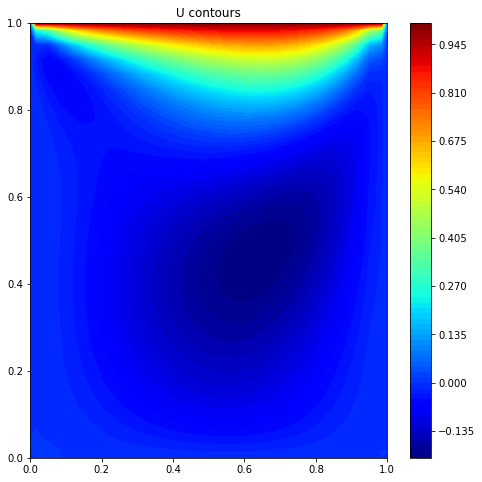

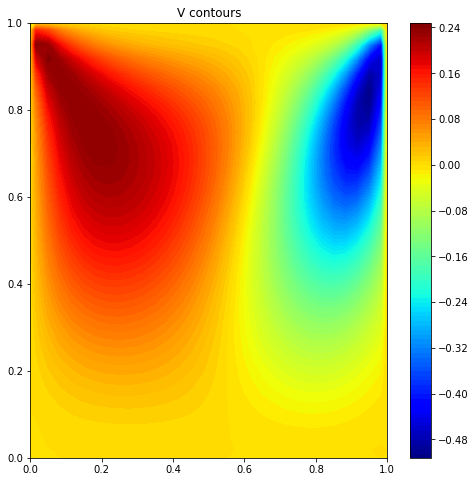

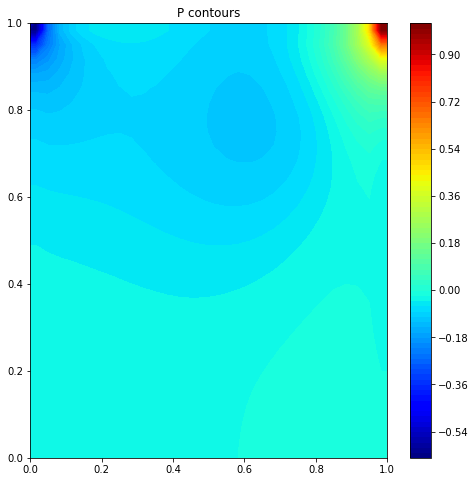

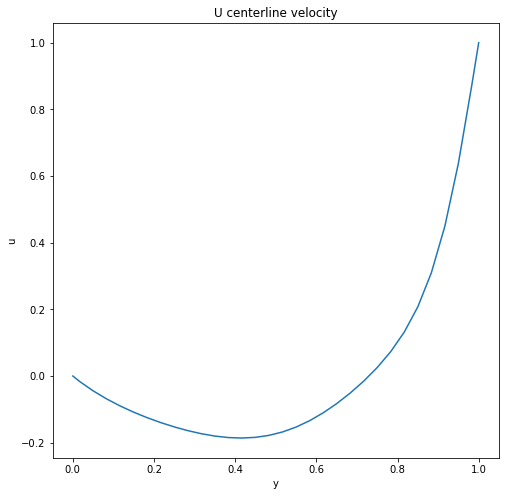

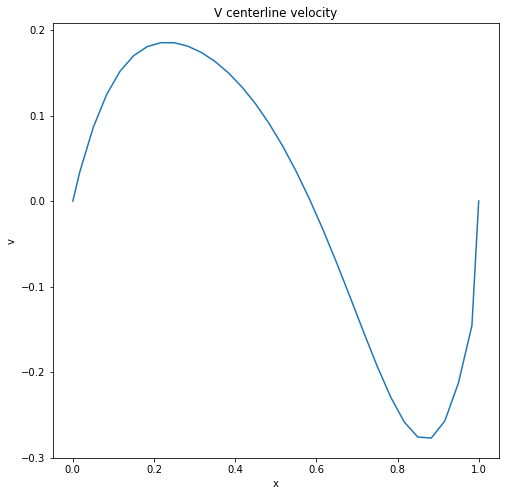

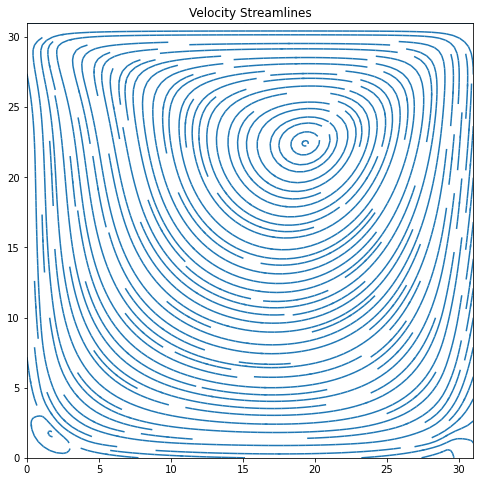

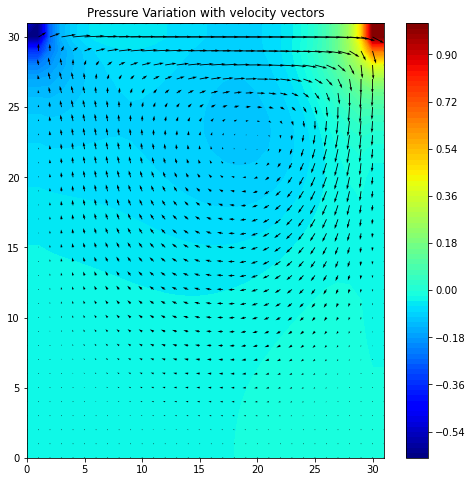

In [324]:
CFD_Lid_Driven_Cavity(u,v,u_star,v_star,u_face,v_face,p,Sx,Sy,aP,aE,aW,aN,aS,alpha_uv,epsilon_uv,max_inner_iteration_uv,l2_norm_x,l2_norm_y,aP_pres,aE_pres,aW_pres,aN_pres,aS_pres,Sp,p_prime,dummy_alphaP,epsilon_p,max_inner_iteration_p,l2_norm_p,p_star)

### Simulation results for Re = 500

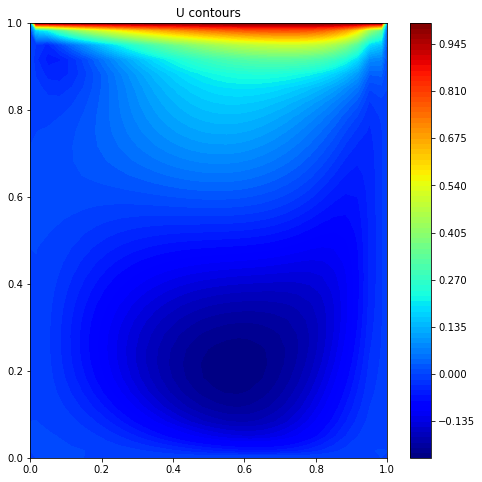

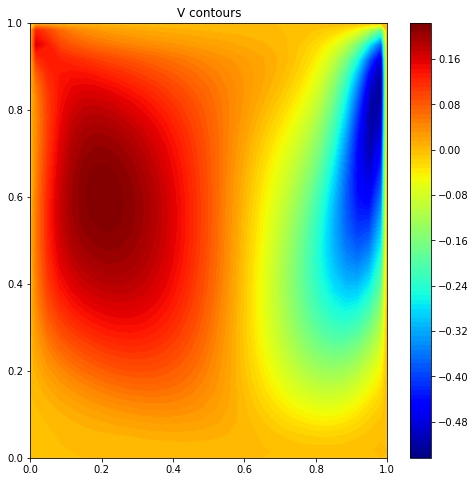

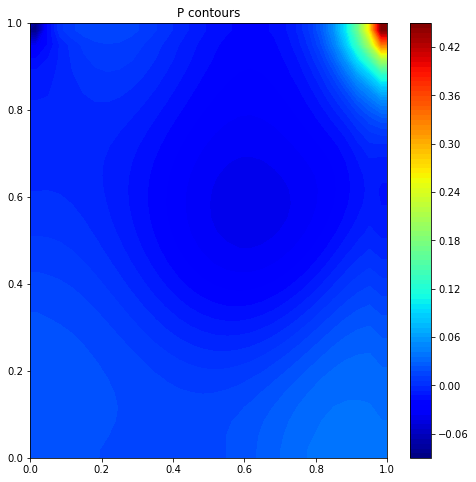

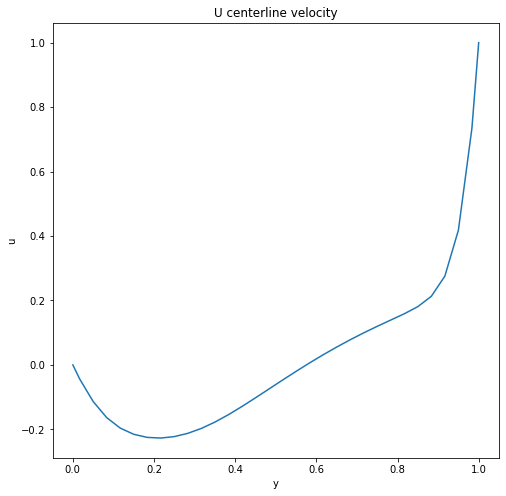

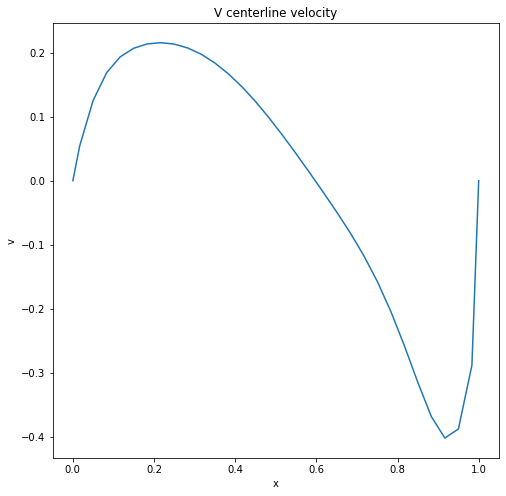

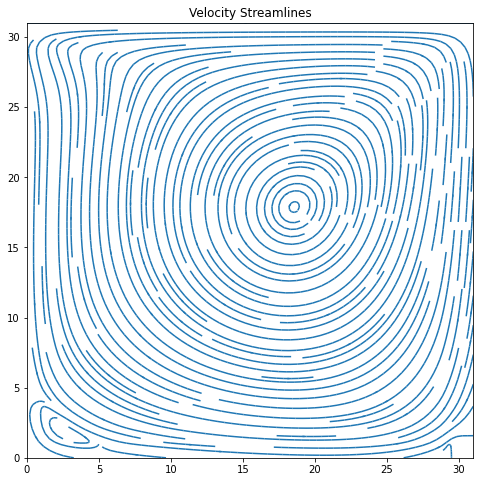

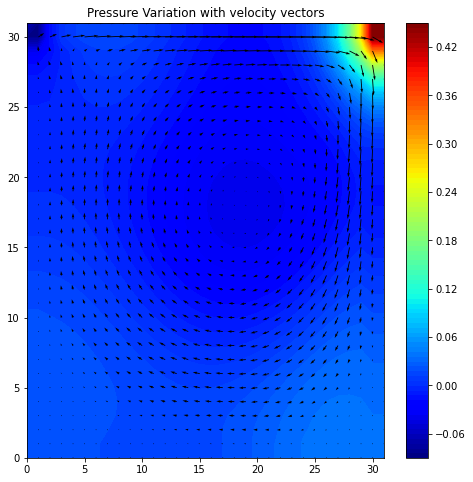

In [272]:
CFD_Lid_Driven_Cavity(u,v,u_star,v_star,u_face,v_face,p,Sx,Sy,aP,aE,aW,aN,aS,alpha_uv,epsilon_uv,max_inner_iteration_uv,l2_norm_x,l2_norm_y,aP_pres,aE_pres,aW_pres,aN_pres,aS_pres,Sp,p_prime,dummy_alphaP,epsilon_p,max_inner_iteration_p,l2_norm_p,p_star)

### Simulation results for Re = 1000

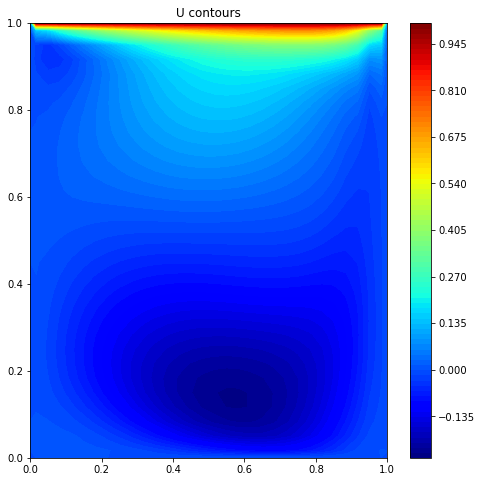

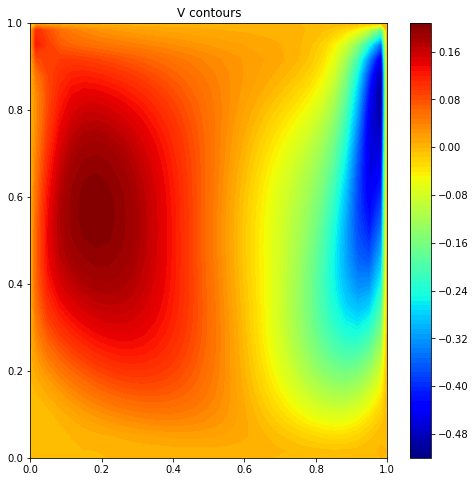

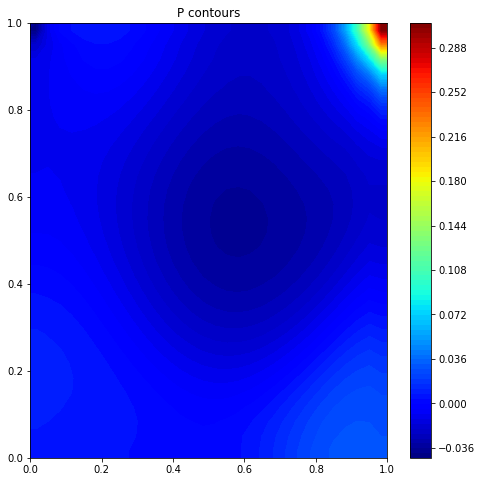

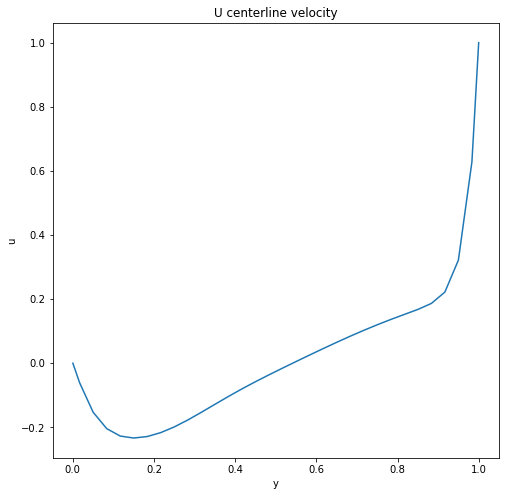

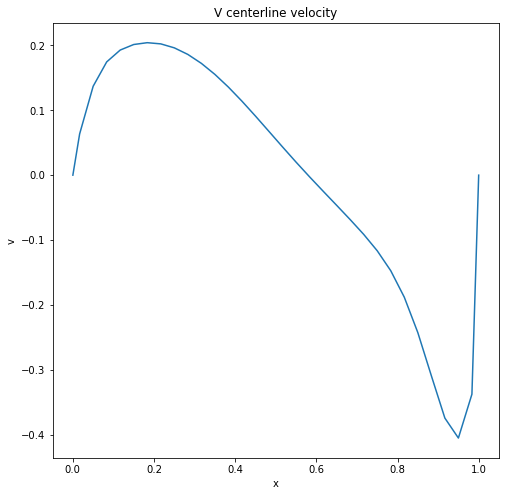

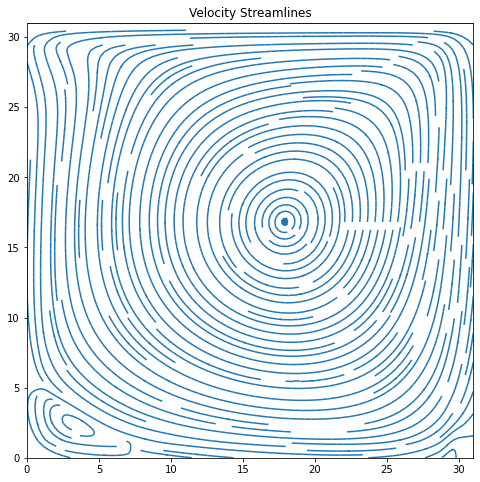

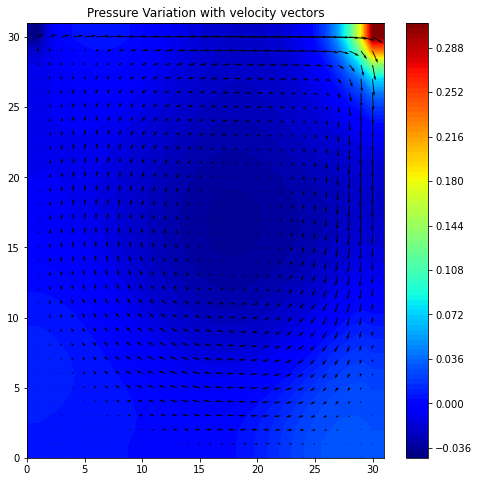

In [287]:
CFD_Lid_Driven_Cavity(u,v,u_star,v_star,u_face,v_face,p,Sx,Sy,aP,aE,aW,aN,aS,alpha_uv,epsilon_uv,max_inner_iteration_uv,l2_norm_x,l2_norm_y,aP_pres,aE_pres,aW_pres,aN_pres,aS_pres,Sp,p_prime,dummy_alphaP,epsilon_p,max_inner_iteration_p,l2_norm_p,p_star)

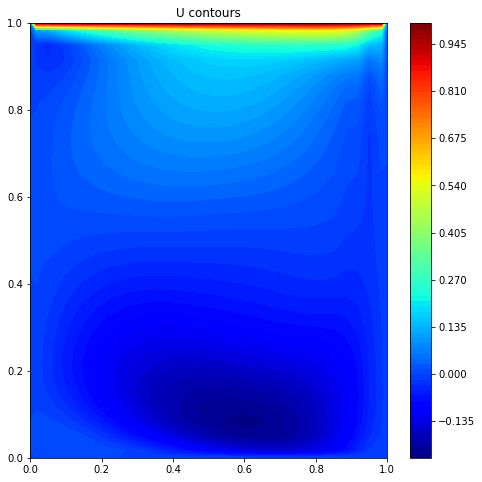

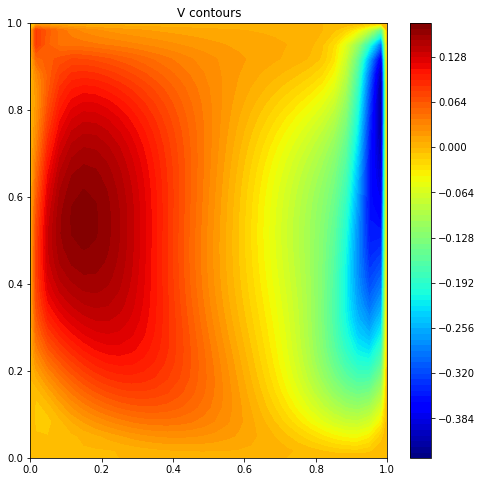

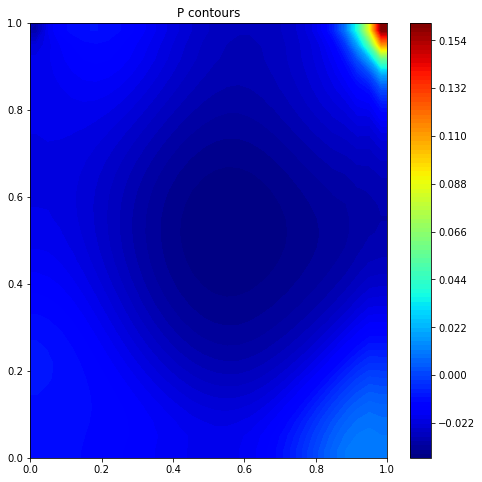

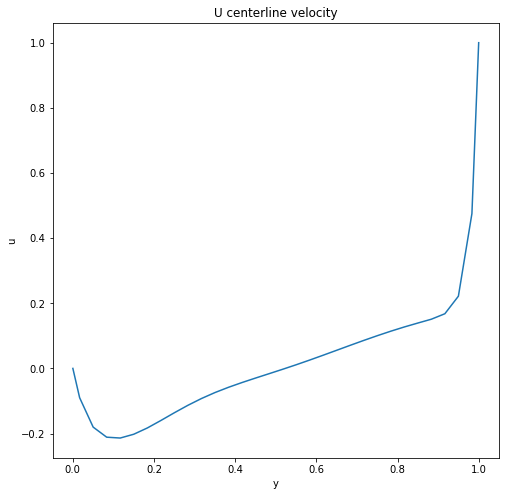

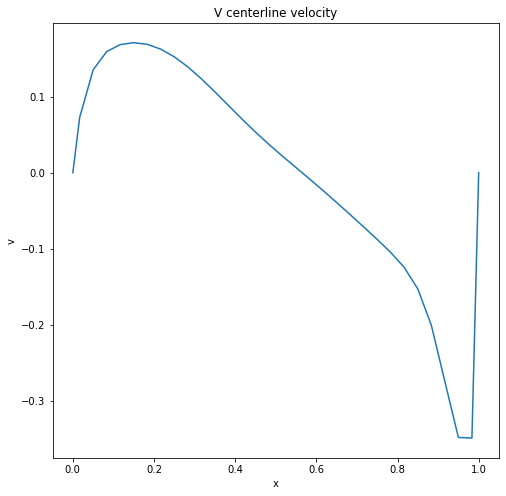

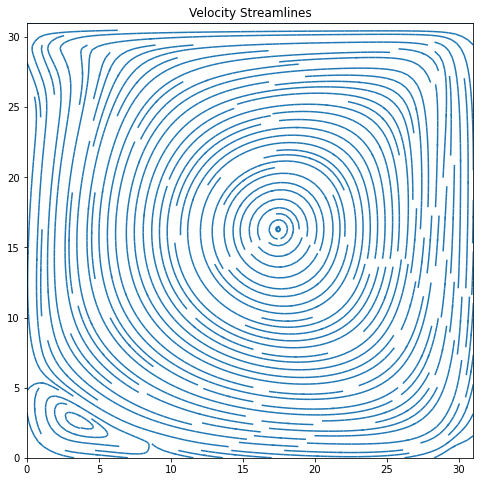

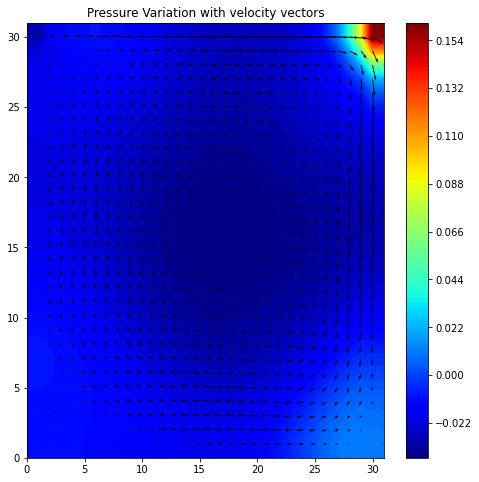

In [302]:
CFD_Lid_Driven_Cavity(u,v,u_star,v_star,u_face,v_face,p,Sx,Sy,aP,aE,aW,aN,aS,alpha_uv,epsilon_uv,max_inner_iteration_uv,l2_norm_x,l2_norm_y,aP_pres,aE_pres,aW_pres,aN_pres,aS_pres,Sp,p_prime,dummy_alphaP,epsilon_p,max_inner_iteration_p,l2_norm_p,p_star)